In [ ]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = True
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

import sys

sys.setrecursionlimit(10**9)
if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
from collections import defaultdict, deque

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    UnionFind,
    calc_dist,
    calc_rectangle_dist_min_max,
    construct_dag_and_rdag_from_edges,
    construct_dag_from_edges,
    construct_dist_matrix,
    construct_dist_matrix_rectangle,
    construct_graph,
    construct_graph_from_list,
    construct_sorted_edges,
    cut_graph,
    divide_interval,
    exponential_schedule,
    is_overlap,
    kruskals_algorithm,
    linear_schedule,
    my_deepcopy,
    prim,
    prim_k,
    prim_vs,
    priority_topological_sort,
    scc,
    scc_construct,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

### 先端をひたすら延ばす

- not_used
- graph[v] = deque(q) ソート済み

- for グループ
  - pre_v = not_used からランダム選択
  - not_used -= pre_v
  - group_cnt = 1
  - while 追加グループ数 < グループ数:
    - while graph[pre_v]:
      - next_v = graph[pre_v].pop()
      - if next_v not in not_used:
        - continue
      - group_cnt += 1
      - not_used.add(next_v)
      - pre_v = next_v
      - break


In [25]:
file_num = 0
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [ ]:
def greedy_simple_n(env):
    graph = construct_graph_from_list(env.cneter_points)
    for i in range(env.N):
        graph[i] = deque([v for _, v in graph[i]])

    ans_edges = [[] for _ in range(env.M)]
    ans_vs = [[] for _ in range(env.M)]

    used = set()
    not_used = set(list(range(env.N)))

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)
    for gi, g_num in groups:
        pre_v = not_used.pop()
        used.add(pre_v)
        ans_vs[gi].append(pre_v)
        group_cnt = 1
        while group_cnt < g_num:
            next_v = None
            while True:
                next_v = graph[pre_v].popleft()
                if next_v not in used:
                    break
            used.add(next_v)
            not_used.remove(next_v)
            ans_edges[gi].append((pre_v, next_v))
            ans_vs[gi].append(next_v)
            group_cnt += 1
            pre_v = next_v
    return ans_vs, ans_edges

In [ ]:
ans_vs, ans_edges = greedy_simple_n(env)

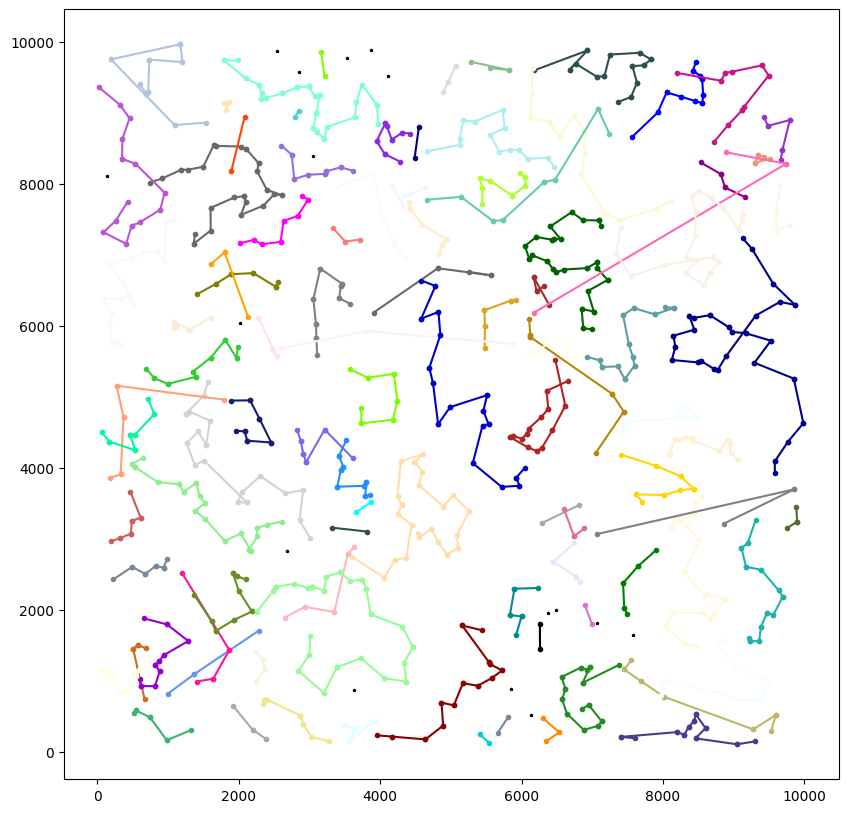

In [27]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def get_color(i):
    colors = list(matplotlib.colors.CSS4_COLORS.values())
    return colors[i % len(colors)]


def draw_answer(ans_v, ans_edges):
    correct_coords = np.array(env.cneter_points)
    plt.figure(figsize=(10, 10))

    for g, (vs, edges) in enumerate(zip(ans_v, ans_edges)):
        if len(vs) == 1:
            coord = correct_coords[vs][0]
            plt.scatter(coord[0], coord[1], color="black", marker="*", s=3)
        vs = np.array(vs)
        edges = np.array(edges)
        for e in edges:
            cs = correct_coords[e]
            plt.plot(
                cs[:, 0],
                cs[:, 1],
                color=get_color(g),
                marker="o",
                markersize=3,
            )
    plt.show()


draw_answer(ans_vs, ans_edges)